### Statsforecast EDA (Autocorrelation plots)

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#212946',
    'axes.facecolor': '#212946',
    'savefig.facecolor':'#212946',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'grid.color': '#2A3459',
    'grid.linewidth': '1',
    'text.color': '0.9',
    'axes.labelcolor': '0.9',
    'xtick.color': '0.9',
    'ytick.color': '0.9',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,7)

In [14]:
Y_df = pd.read_csv('gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [15]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [16]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [19]:
Y_df['y'] = Y_df['power_draw_W']
Y_df['ds'] = Y_df['timestamp']

In [25]:
# This is the standard format for Nixtla.
df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id                  ds          y
264388  10217518336509_gpu0 2021-06-07 20:24:30  54.939016
471025  10217518336509_gpu0 2021-06-07 20:24:30  46.433710
264389  10217518336509_gpu0 2021-06-07 20:24:40  53.556915
471026  10217518336509_gpu0 2021-06-07 20:24:40  46.569681
264390  10217518336509_gpu0 2021-06-07 20:24:50  52.611935

Number of unique time series (job-gpu combinations): 414


In [26]:
# Filter to one specific series
df_one = df[df["unique_id"] == "10217518336509_gpu0"].copy()
df_one.head()

,unique_id,ds,y
264388,10217518336509_gpu0,2021-06-07 20:24:30,54.939016
471025,10217518336509_gpu0,2021-06-07 20:24:30,46.433710
264389,10217518336509_gpu0,2021-06-07 20:24:40,53.556915
471026,10217518336509_gpu0,2021-06-07 20:24:40,46.569681
264390,10217518336509_gpu0,2021-06-07 20:24:50,52.611935


In [27]:
df_one["ds"] = pd.to_datetime(df_one["ds"])


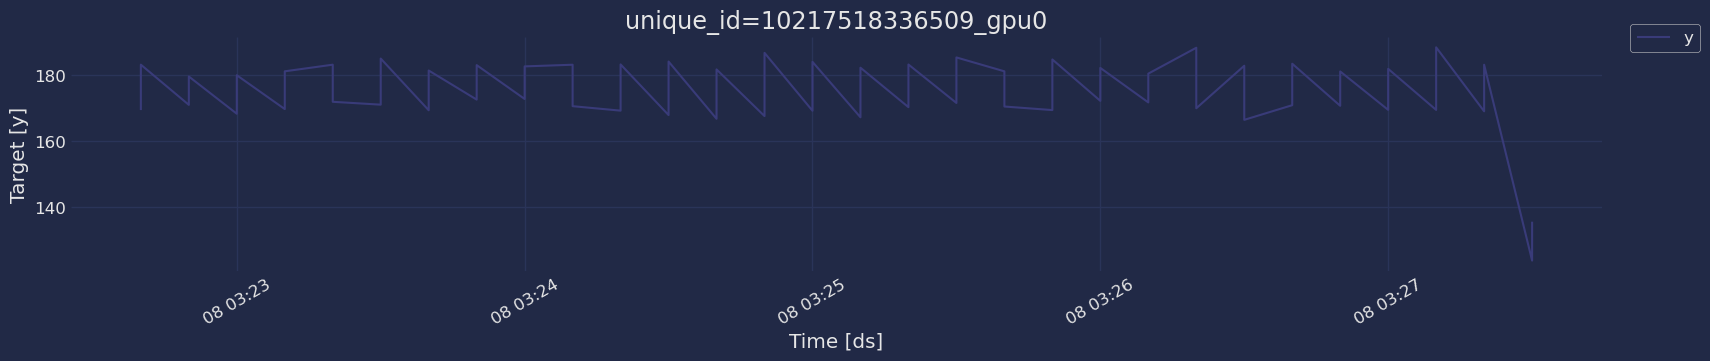

In [29]:
from statsforecast import StatsForecast

StatsForecast.plot(df_one, max_insample_length=30*2)

In [30]:
df = df_one

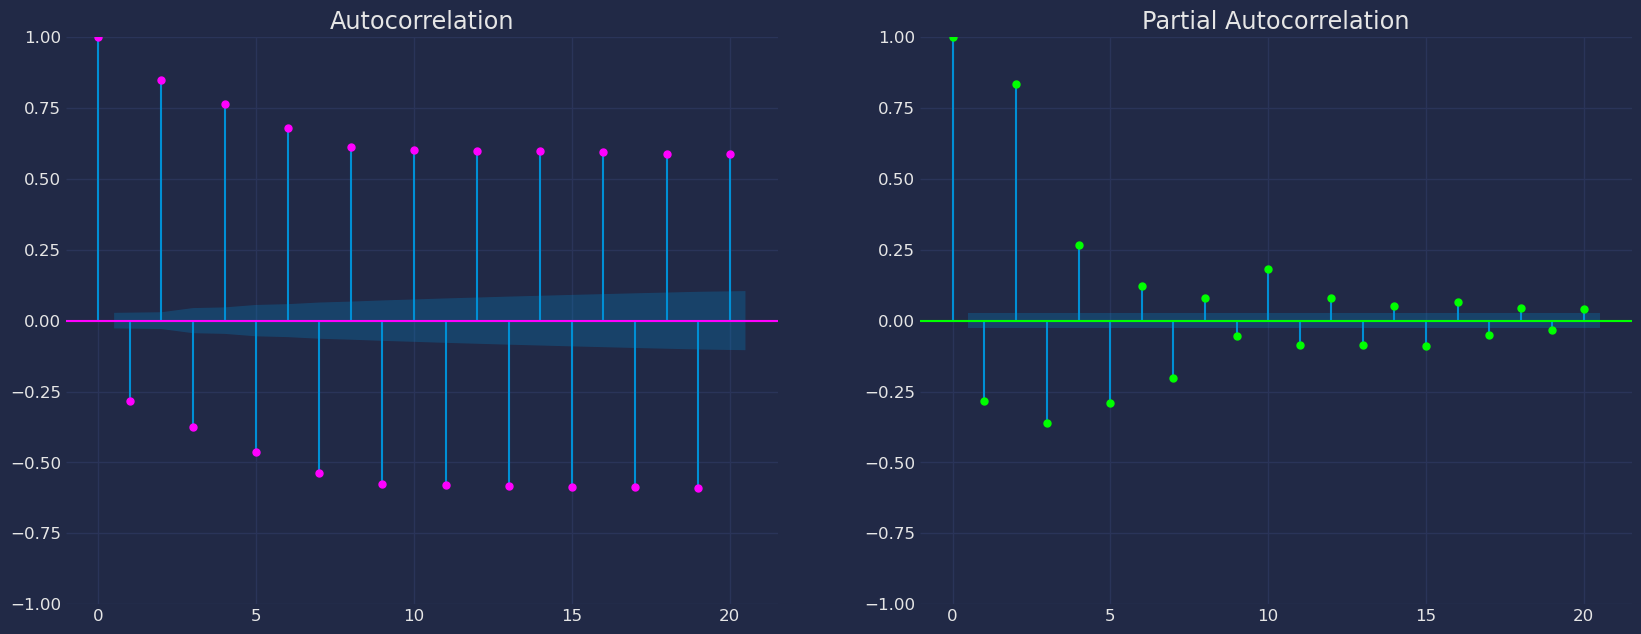

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=20, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

# Plot
plot_pacf(df["y"],  lags=20, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

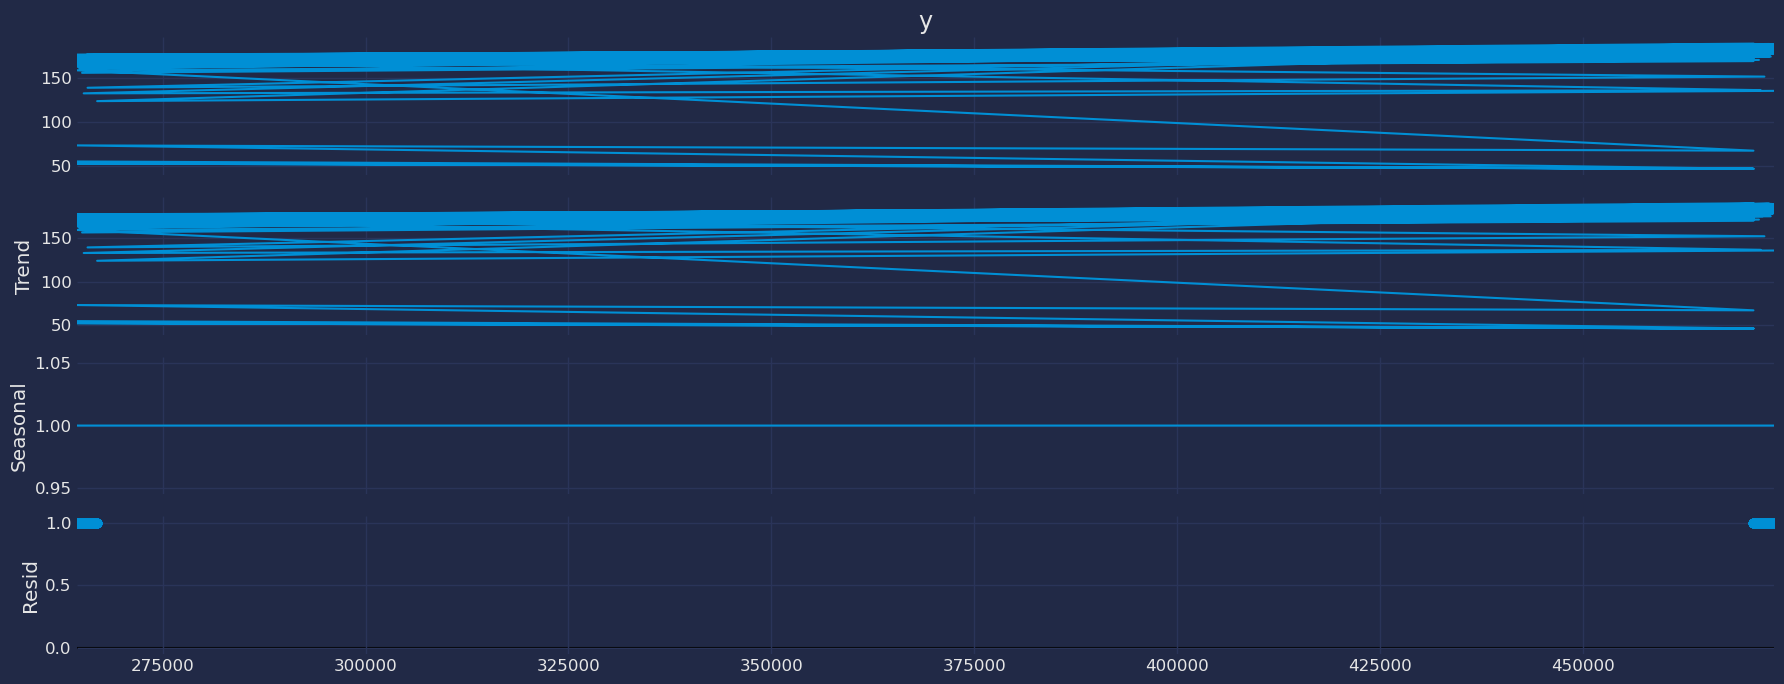

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "multiply", period=1)
a.plot();